<!-- type: how-to -->
# Lag-Aware ModMRMR To ForecastPrepContract

This recipe shows a minimal task-driven flow:

1. run univariate triage on the target,
2. run lag-aware ModMRMR on measured and known-future covariates,
3. build a `ForecastPrepContract` with `lag_aware_result=...`,
4. render the contract markdown and compact lag rows,
5. inspect how measured and known-future covariates appear in the contract.

## Setup

The setup cell resolves the repo root under local execution or `nbconvert`, switches plotting to `Agg` for batch safety, and pre-creates `outputs/notebooks/recipes/lag_aware_mod_mrmr_to_forecast_prep_contract/{figures,tables}`.

> Prerequisite: these lag-aware notebooks require the local core checkout until v0.4.3 is published.

```bash
export FORECASTABILITY_LOCAL_DEV=1
bash ../ami/scripts/bootstrap_local_workspace.sh
```

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

try:
    from forecastability import (
        LagAwareModMRMRConfig,
        PairwiseScorerSpec,
        TriageRequest,
        build_forecast_prep_contract,
        forecast_prep_contract_to_lag_table,
        forecast_prep_contract_to_markdown,
        run_lag_aware_mod_mrmr,
        run_triage,
    )
except ImportError as exc:
    raise ImportError(
        "Lag-aware public imports are unavailable in the installed forecastability package. "
        "These notebooks require the local core checkout until v0.4.3 is published.\n\n"
        "Run:\n"
        "export FORECASTABILITY_LOCAL_DEV=1\n"
        "bash ../ami/scripts/bootstrap_local_workspace.sh"
    ) from exc

from forecastability.triage import AnalysisGoal

CWD = Path.cwd().resolve()
if (CWD / 'pyproject.toml').exists() and (CWD / 'recipes').exists():
    REPO_ROOT = CWD
elif CWD.name == 'recipes' and (CWD.parent / 'pyproject.toml').exists():
    REPO_ROOT = CWD.parent
else:
    raise RuntimeError(
        'Run this notebook from the forecastability-examples repo root or its recipes directory.'
    )

os.chdir(REPO_ROOT)

NOTEBOOK_STEM = 'lag_aware_mod_mrmr_to_forecast_prep_contract'
OUTPUT_ROOT = REPO_ROOT / 'outputs' / 'notebooks' / 'recipes' / NOTEBOOK_STEM
FIG_DIR = OUTPUT_ROOT / 'figures'
TABLE_DIR = OUTPUT_ROOT / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', 160)
pd.set_option('display.precision', 4)


def _relative_output_path(path: Path) -> str:
    try:
        return str(path.relative_to(REPO_ROOT))
    except ValueError:
        return str(path)


print('Repo root: .')
print(f'Figure dir: {_relative_output_path(FIG_DIR)}')
print(f'Table dir: {_relative_output_path(TABLE_DIR)}')

Repo root: .
Figure dir: outputs/notebooks/recipes/lag_aware_mod_mrmr_to_forecast_prep_contract/figures
Table dir: outputs/notebooks/recipes/lag_aware_mod_mrmr_to_forecast_prep_contract/tables


## Build A Small Synthetic Example

The panel below has one measured driver, one near-duplicate sensor, one known-future calendar covariate, and one pure-noise covariate.

In [2]:
def _ar1(n: int, *, phi: float, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    values = np.zeros(n, dtype=float)
    noise = rng.normal(scale=1.0, size=n)
    for idx in range(1, n):
        values[idx] = phi * values[idx - 1] + noise[idx]
    return values


rng = np.random.default_rng(SEED)
n = 480
time_index = np.arange(n, dtype=int)
latent_driver = _ar1(n, phi=0.82, seed=SEED + 1)
calendar_flag = ((time_index % 7) >= 5).astype(float)

target = np.zeros(n, dtype=float)
noise = rng.normal(scale=0.16, size=n)
for idx in range(5, n):
    target[idx] = (
        0.60 * target[idx - 1]
        - 0.12 * target[idx - 4]
        + 0.38 * latent_driver[idx - 3]
        + 0.10 * calendar_flag[idx]
        + noise[idx]
    )

panel = pd.DataFrame(
    {
        'target': target,
        'promo_index': latent_driver + 0.08 * rng.normal(size=n),
        'promo_duplicate': latent_driver + 0.02 * rng.normal(size=n),
        'calendar_flag': calendar_flag,
        'noise_sensor': rng.normal(size=n),
    },
    index=pd.RangeIndex(n, name='t'),
)

covariates = {
    column: panel[column].to_numpy(dtype=float)
    for column in panel.columns
    if column != 'target'
}

display(panel.head())

,target,promo_index,promo_duplicate,calendar_flag,noise_sensor
t,,,,,
0,0.0,0.0178,0.0323,0.0,-0.6646
1,0.0,0.7928,0.6808,0.0,0.3606
2,0.0,-0.0221,-0.0495,0.0,-1.3907
3,0.0,-0.8863,-0.9350,0.0,1.4387
4,0.0,-2.7613,-2.7574,0.0,-0.1440


## Run Triage And Lag-Aware ModMRMR

Fast mode uses `mutual_info_sklearn` for relevance and `spearman_abs` for redundancy plus target-history novelty. Target-history novelty is enabled here by passing both `target_lags` and `target_history_scorer`.

In [3]:
triage_result = run_triage(
    TriageRequest(
        series=panel['target'].to_numpy(dtype=float),
        goal=AnalysisGoal.univariate,
        max_lag=16,
        n_surrogates=99,
        random_state=SEED,
    )
)

relevance_spec = PairwiseScorerSpec(
    name='mutual_info_sklearn',
    backend='sklearn',
    normalization='rank_percentile',
    significance_method='none',
    settings={'n_neighbors': 8},
)
similarity_spec = PairwiseScorerSpec(
    name='spearman_abs',
    backend='scipy',
    normalization='rank_percentile',
    significance_method='none',
)

lag_aware_config = LagAwareModMRMRConfig(
    forecast_horizon=2,
    availability_margin=0,
    candidate_lags=[1, 2, 3, 4, 5],
    known_future_covariates={'calendar_flag': 'calendar'},
    target_lags=[2, 4],
    max_selected_features=4,
    relevance_scorer=relevance_spec,
    redundancy_scorer=similarity_spec,
    target_history_scorer=similarity_spec,
)

lag_aware_result = run_lag_aware_mod_mrmr(
    target=panel['target'].to_numpy(dtype=float),
    covariates=covariates,
    config=lag_aware_config,
    random_state=SEED,
    run_id='recipe_lag_aware_to_contract',
)

selected_df = pd.DataFrame(
    [
        {
            'feature_name': item.feature_name,
            'covariate_name': item.covariate_name,
            'lag': item.lag,
            'known_future': item.is_known_future,
            'known_future_provenance': item.known_future_provenance,
            'selection_rank': item.selection_rank,
            'relevance': item.relevance,
            'max_redundancy': item.max_redundancy,
            'target_history_redundancy': item.target_history_redundancy,
            'final_score': item.final_score,
        }
        for item in lag_aware_result.selected
    ]
)

print(f'Triage readiness: {triage_result.readiness.status}')
print(f'Triage primary lags: {triage_result.interpretation.primary_lags if triage_result.interpretation is not None else []}')
display(selected_df)

Triage readiness: clear
Triage primary lags: [1]


,feature_name,covariate_name,lag,known_future,known_future_provenance,selection_rank,relevance,max_redundancy,target_history_redundancy,final_score
0,x_noise_sensor_lag3,noise_sensor,3,False,NaN,1,0.5294,0.0000,0.3235,0.3581
1,x_calendar_flag_lag4,calendar_flag,4,True,calendar,2,0.2941,0.1103,0.1471,0.2232
2,x_promo_index_lag3,promo_index,3,False,NaN,3,0.9412,0.3824,0.7059,0.1710
3,x_noise_sensor_lag2,noise_sensor,2,False,NaN,4,0.4118,0.8162,0.2941,0.0534


## Build The Contract And Inspect Covariate Roles

The contract below uses the lag-aware result as its covariate source. The rendered markdown and lag rows make it easy to see which covariates are treated as ordinary measured history versus explicit known-future inputs.

In [4]:
contract = build_forecast_prep_contract(
    triage_result,
    horizon=2,
    target_frequency='D',
    lag_aware_result=lag_aware_result,
    add_calendar_features=False,
)

contract_markdown = forecast_prep_contract_to_markdown(contract)
contract_rows_df = pd.DataFrame(forecast_prep_contract_to_lag_table(contract))
role_df = pd.DataFrame(
    [
        {'bucket': 'past_covariates', 'names': contract.past_covariates},
        {'bucket': 'future_covariates', 'names': contract.future_covariates},
    ]
)

contract_markdown_path = TABLE_DIR / 'forecast_prep_contract.md'
contract_rows_path = TABLE_DIR / 'forecast_prep_contract_rows.csv'
role_path = TABLE_DIR / 'forecast_prep_contract_roles.csv'
contract_markdown_path.write_text(contract_markdown, encoding='utf-8')
contract_rows_df.to_csv(contract_rows_path, index=False)
role_df.to_csv(role_path, index=False)

print(f'Wrote contract markdown: {_relative_output_path(contract_markdown_path)}')
print(f'Wrote contract rows: {_relative_output_path(contract_rows_path)}')
print(f'Wrote role summary: {_relative_output_path(role_path)}')

display(Markdown(contract_markdown))
display(contract_rows_df)
display(role_df)

Wrote contract markdown: outputs/notebooks/recipes/lag_aware_mod_mrmr_to_forecast_prep_contract/tables/forecast_prep_contract.md
Wrote contract rows: outputs/notebooks/recipes/lag_aware_mod_mrmr_to_forecast_prep_contract/tables/forecast_prep_contract_rows.csv
Wrote role summary: outputs/notebooks/recipes/lag_aware_mod_mrmr_to_forecast_prep_contract/tables/forecast_prep_contract_roles.csv


# Forecast Prep Contract

## Metadata

- source_goal: lagged_exogenous
- blocked: False
- readiness_status: clear
- confidence_label: medium
- target_frequency: D
- horizon: 2
- contract_version: 0.3.4

## Target Lags

**recommended_target_lags:**
- 1

**recommended_seasonal_lags:**
(none)

**excluded_target_lags:**
(none)

**lag_rationale:**
- lag 1 is the strongest non-seasonal lag

## Model Families

**recommended_families:**
(none)

**baseline_families:**
- naive
- seasonal_naive

## Covariates

**past_covariates:**
- noise_sensor
- promo_index

**selected_covariate_lags:**
| axis | kind | driver | selected_lags | feature_names |
| --- | --- | --- | --- | --- |
| future | known_future:calendar | calendar_flag | 4 | x_calendar_flag_lag4 |
| past | measured | noise_sensor | 2, 3 | x_noise_sensor_lag2, x_noise_sensor_lag3 |
| past | measured | promo_index | 3 | x_promo_index_lag3 |

**covariate_notes:**
- future covariate calendar_flag: lags [4]
- past covariate noise_sensor: lags [2, 3]
- past covariate promo_index: lags [3]

**future_covariates:**
- calendar_flag

**calendar_features:**
(none)

**calendar_locale:** None

**rejected_covariates:**
(none)

**target_history_context:**
- enabled: True
- target_lags: [2, 4]
- scorer_name: spearman_abs
- normalization_strategy: rank_percentile
- penalized_selected_features: 4
- max_selected_redundancy: 0.7058823529411765
- notes:
- target-history novelty scored with spearman_abs over target lags [2, 4]
- 4 selected feature(s) carried non-zero target-history redundancy

## Notes

**caution_flags:**
(none)

**downstream_notes:**
(none)

**transformation_hints:**
(none)


,driver,axis,role,lag,selected_for_handoff,rationale,feature_name,future_known_required,known_future_provenance,kind
0,target,target,direct,1,True,lag 1 is the strongest non-seasonal lag,NaN,NaN,NaN,NaN
1,noise_sensor,past,past,2,True,"lag-aware ModMRMR selected sparse measured lags: [2, 3]",x_noise_sensor_lag2,False,NaN,measured
2,noise_sensor,past,past,3,True,"lag-aware ModMRMR selected sparse measured lags: [2, 3]",x_noise_sensor_lag3,False,NaN,measured
3,promo_index,past,past,3,True,lag-aware ModMRMR selected sparse measured lags: [3],x_promo_index_lag3,False,NaN,measured
4,calendar_flag,future,future,4,True,lag-aware ModMRMR selected known-future lags: [4] (provenance=calendar),x_calendar_flag_lag4,True,calendar,known_future:calendar


,bucket,names
0,past_covariates,"[noise_sensor, promo_index]"
1,future_covariates,[calendar_flag]


CausalRivers panel shape: (7227, 9)
CausalRivers triage readiness: clear
CausalRivers target-history lags: [4, 5]
CausalRivers scientific raw negative-control hits: ['station_67', 'station_71', 'station_99']
Downstream note: the multi-origin MLForecast pass reuses one fitted model to mirror notebook 07.
Treat it as a hand-off sanity check on false positives and skill, not as a leak-free benchmark.
Wrote CausalRivers selected rows: outputs/notebooks/recipes/lag_aware_mod_mrmr_to_forecast_prep_contract/tables/causal_rivers_selected_rows.csv
Wrote CausalRivers contract markdown: outputs/notebooks/recipes/lag_aware_mod_mrmr_to_forecast_prep_contract/tables/causal_rivers_forecast_prep_contract.md
Wrote CausalRivers contract rows: outputs/notebooks/recipes/lag_aware_mod_mrmr_to_forecast_prep_contract/tables/causal_rivers_forecast_prep_contract_rows.csv
Wrote CausalRivers downstream summary: outputs/notebooks/recipes/lag_aware_mod_mrmr_to_forecast_prep_contract/tables/causal_rivers_downstream

,feature_name,covariate_name,role,lag,selection_rank,final_score
0,x_station_71_lag4,station_71,negative/control,4,1,0.6081
1,x_station_490_lag4,station_490,positive,4,2,0.1820
2,x_station_758_lag4,station_758,positive,4,3,0.1276
3,x_station_1095_lag4,station_1095,positive,4,4,0.0710
4,x_station_313_lag4,station_313,positive,4,5,0.0400
5,x_station_99_lag11,station_99,negative/control,11,6,0.0309
6,x_station_67_lag5,station_67,negative/control,5,7,0.0280
7,x_station_758_lag12,station_758,positive,12,8,0.0275
8,x_station_71_lag6,station_71,negative/control,6,9,0.0250
9,x_station_758_lag8,station_758,positive,8,10,0.0231


# Forecast Prep Contract

## Metadata

- source_goal: lagged_exogenous
- blocked: False
- readiness_status: clear
- confidence_label: medium
- target_frequency: 6h
- horizon: 4
- contract_version: 0.3.4

## Target Lags

**recommended_target_lags:**
- 1

**recommended_seasonal_lags:**
(none)

**excluded_target_lags:**
(none)

**lag_rationale:**
- lag 1 is the strongest non-seasonal lag
- lag 2 is secondary under current confidence
- lag 3 is secondary under current confidence
- lag 4 is secondary under current confidence
- lag 5 is secondary under current confidence

## Model Families

**recommended_families:**
(none)

**baseline_families:**
- naive
- seasonal_naive

## Covariates

**past_covariates:**
- station_1095
- station_313
- station_490
- station_67
- station_71
- station_758
- station_99

**selected_covariate_lags:**
| axis | kind | driver | selected_lags | feature_names |
| --- | --- | --- | --- | --- |
| past | measured | station_1095 | 4 | x_station_1095_lag4 |
| past | measured | station_313 | 4 | x_station_313_lag4 |
| past | measured | station_490 | 4 | x_station_490_lag4 |
| past | measured | station_67 | 5 | x_station_67_lag5 |
| past | measured | station_71 | 4, 6, 8 | x_station_71_lag4, x_station_71_lag6, x_station_71_lag8 |
| past | measured | station_758 | 4, 5, 8, 12 | x_station_758_lag4, x_station_758_lag5, x_station_758_lag8, x_station_758_lag12 |
| past | measured | station_99 | 11 | x_station_99_lag11 |

**covariate_notes:**
- past covariate station_1095: lags [4]
- past covariate station_313: lags [4]
- past covariate station_490: lags [4]
- past covariate station_67: lags [5]
- past covariate station_71: lags [4, 6, 8]
- past covariate station_758: lags [4, 5, 8, 12]
- past covariate station_99: lags [11]

**future_covariates:**
(none)

**calendar_features:**
(none)

**calendar_locale:** None

**rejected_covariates:**
(none)

**target_history_context:**
- enabled: True
- target_lags: [4, 5]
- scorer_name: catt_knn_mi
- normalization_strategy: rank_percentile
- penalized_selected_features: 12
- max_selected_redundancy: 0.8263888888888888
- notes:
- target-history novelty scored with catt_knn_mi over target lags [4, 5]
- 12 selected feature(s) carried non-zero target-history redundancy

## Notes

**caution_flags:**
(none)

**downstream_notes:**
(none)

**transformation_hints:**
(none)


,driver,axis,role,lag,selected_for_handoff,rationale,feature_name,future_known_required,known_future_provenance,kind
0,target,target,direct,1,True,lag 1 is the strongest non-seasonal lag,NaN,NaN,NaN,NaN
1,station_1095,past,past,4,True,lag-aware ModMRMR selected sparse measured lags: [4],x_station_1095_lag4,False,NaN,measured
2,station_313,past,past,4,True,lag-aware ModMRMR selected sparse measured lags: [4],x_station_313_lag4,False,NaN,measured
3,station_490,past,past,4,True,lag-aware ModMRMR selected sparse measured lags: [4],x_station_490_lag4,False,NaN,measured
4,station_67,past,past,5,True,lag-aware ModMRMR selected sparse measured lags: [5],x_station_67_lag5,False,NaN,measured
5,station_71,past,past,4,True,"lag-aware ModMRMR selected sparse measured lags: [4, 6, 8]",x_station_71_lag4,False,NaN,measured
6,station_71,past,past,6,True,"lag-aware ModMRMR selected sparse measured lags: [4, 6, 8]",x_station_71_lag6,False,NaN,measured
7,station_71,past,past,8,True,"lag-aware ModMRMR selected sparse measured lags: [4, 6, 8]",x_station_71_lag8,False,NaN,measured
8,station_758,past,past,4,True,"lag-aware ModMRMR selected sparse measured lags: [4, 5, 8, 12]",x_station_758_lag4,False,NaN,measured
9,station_758,past,past,5,True,"lag-aware ModMRMR selected sparse measured lags: [4, 5, 8, 12]",x_station_758_lag5,False,NaN,measured


,variant,driver_count,lag_feature_count,negative_driver_hits,negative_driver_hit_count,negative_driver_importance,single_origin_mae,single_origin_rmse,single_origin_nse,single_origin_naive_mae,single_origin_skill_pct,walk_forward_origin_count,walk_forward_mae,walk_forward_naive_mae,walk_forward_skill_pct
0,scientific_raw,7,12,"station_67, station_71, station_99",3,936,14.845,16.882,-0.392,24.729,39.972,9,2.471,7.286,66.084
1,scientific_drop_known_negatives,4,7,,0,0,13.400,15.470,-0.169,24.729,45.814,9,3.169,7.286,56.505
2,notebook_07_reference_legal_window,4,5,,0,0,12.819,14.601,-0.041,24.729,48.162,9,2.742,7.286,62.372


,variant,driver,role,selected_lags,lag_feature_count,total_importance
12,notebook_07_reference_legal_window,station_313,positive,"[4, 8]",2,1050
14,notebook_07_reference_legal_window,station_758,positive,[12],1,436
11,notebook_07_reference_legal_window,station_1095,positive,[8],1,423
13,notebook_07_reference_legal_window,station_490,positive,[9],1,364
10,scientific_drop_known_negatives,station_758,positive,"[4, 5, 8, 12]",4,1263
7,scientific_drop_known_negatives,station_1095,positive,[4],1,448
8,scientific_drop_known_negatives,station_313,positive,[4],1,427
9,scientific_drop_known_negatives,station_490,positive,[4],1,331
5,scientific_raw,station_758,positive,"[4, 5, 8, 12]",4,781
4,scientific_raw,station_71,negative/control,"[4, 6, 8]",3,449


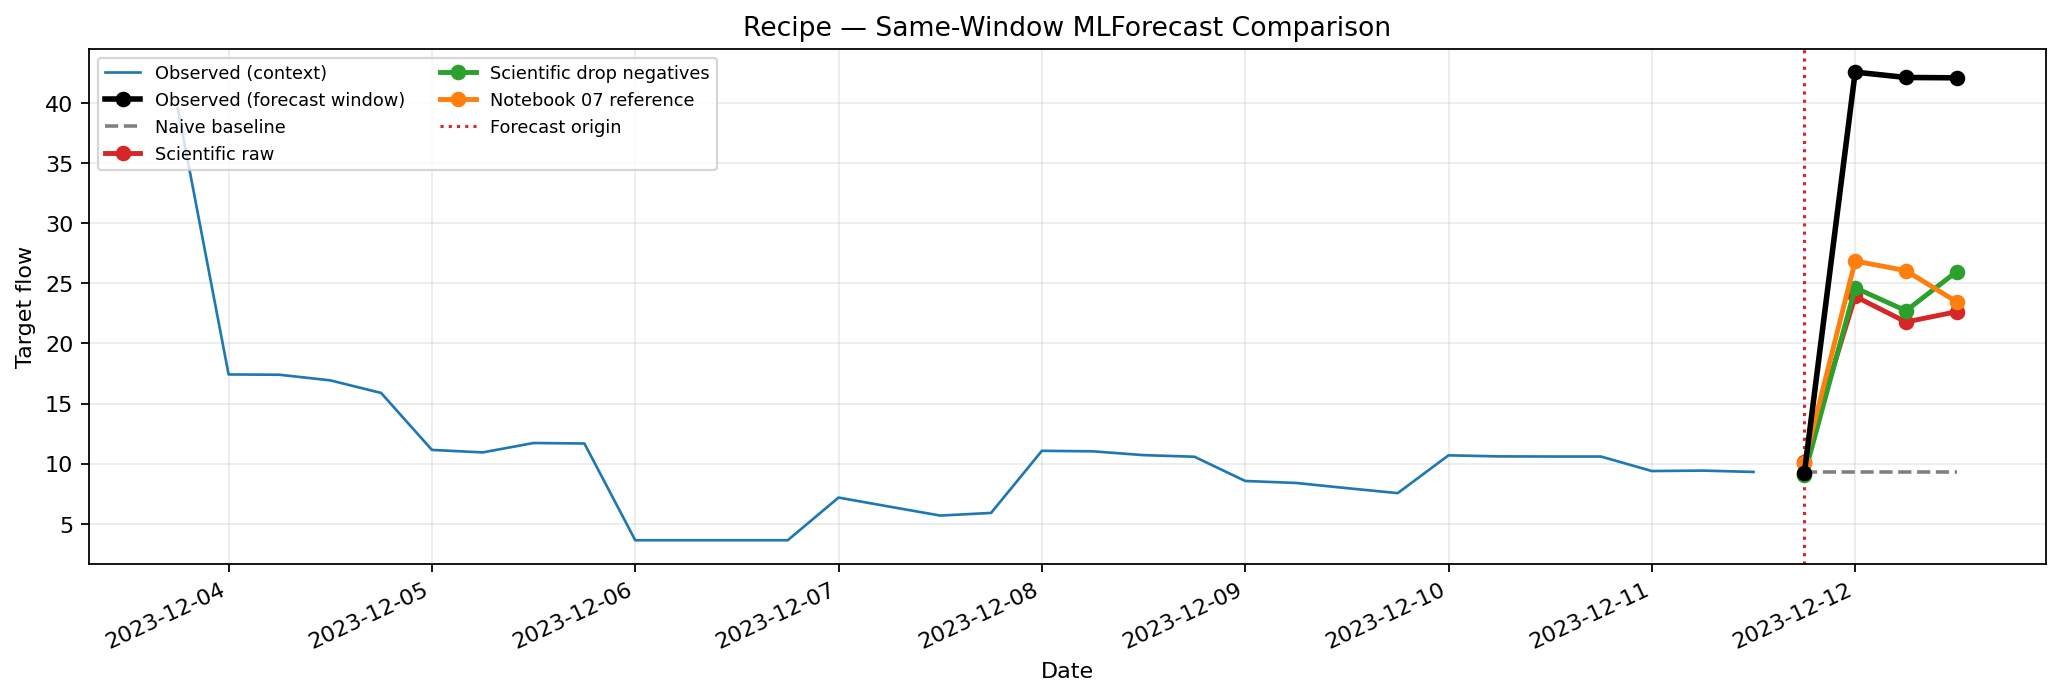

In [5]:
import subprocess
import sys

import lightgbm as lgb
from mlforecast import MLForecast


def _load_recipe_causal_rivers_frame() -> pd.DataFrame:
    data_path = REPO_ROOT / 'data' / 'causal_rivers' / 'east_germany_8stations_6h.parquet'
    if not data_path.exists():
        subprocess.run(
            [sys.executable, str(REPO_ROOT / 'scripts' / 'download_causal_rivers.py')],
            cwd=str(REPO_ROOT),
            check=True,
        )
    frame = pd.read_parquet(data_path)
    frame.columns = [int(column) for column in frame.columns]
    return frame


def _recipe_variant_display_name(variant_name: str) -> str:
    labels = {
        'scientific_raw': 'Scientific raw',
        'scientific_drop_known_negatives': 'Scientific drop negatives',
        'notebook_07_reference_legal_window': 'Notebook 07 reference',
    }
    return labels.get(variant_name, variant_name)


def _recipe_driver_role(driver_name: str) -> str:
    if not driver_name.startswith('station_'):
        return 'other'
    station_id = int(driver_name.split('_', 1)[1])
    if station_id in causal_recipe_positives:
        return 'positive'
    if station_id in causal_recipe_negatives:
        return 'negative/control'
    return 'other'


def _recipe_driver_lag_map(result) -> dict[str, list[int]]:
    mapping: dict[str, list[int]] = {}
    for item in result.selected:
        mapping.setdefault(item.covariate_name, []).append(item.lag)
    return {name: sorted(set(lags)) for name, lags in mapping.items()}


def _build_recipe_downstream_frame(driver_lag_map: dict[str, list[int]]) -> tuple[pd.DataFrame, list[str]]:
    driver_names = sorted(driver_lag_map)
    station_ids = [int(name.split('_', 1)[1]) for name in driver_names]
    base_frame = causal_recipe_panel[[causal_recipe_target_id, *station_ids]].copy()
    base_frame.columns = ['y', *driver_names]
    base_frame['unique_id'] = 'unstrut_978'
    base_frame['ds'] = causal_recipe_panel.index
    base_columns = ['unique_id', 'ds', 'y', *driver_names]
    base_frame = base_frame.reset_index(drop=True)[base_columns]

    for driver_name, lags in driver_lag_map.items():
        for lag in sorted(set(lags)):
            base_frame[f'{driver_name}_lag{lag}'] = base_frame[driver_name].shift(lag)

    lag_feature_cols = [column for column in base_frame.columns if column not in base_columns]
    model_frame = base_frame.drop(columns=driver_names).dropna().reset_index(drop=True)
    return model_frame, lag_feature_cols


def _save_recipe_single_origin_comparison_plot(single_origin_df: pd.DataFrame, *, figure_path: Path) -> None:
    actual_df = (
        single_origin_df[['ds', 'actual', 'naive']]
        .drop_duplicates(subset=['ds'])
        .sort_values('ds')
        .reset_index(drop=True)
    )
    forecast_start = actual_df['ds'].iloc[0]
    context_steps = 8 * causal_recipe_horizon
    context_series = causal_recipe_panel.loc[causal_recipe_panel.index < forecast_start, causal_recipe_target_id].tail(context_steps)

    palette = {
        'scientific_raw': 'tab:red',
        'scientific_drop_known_negatives': 'tab:green',
        'notebook_07_reference_legal_window': 'tab:orange',
    }

    figure_path.parent.mkdir(parents=True, exist_ok=True)
    fig, ax = plt.subplots(figsize=(13, 4.5))
    if not context_series.empty:
        ax.plot(
            context_series.index,
            context_series.to_numpy(),
            label='Observed (context)',
            linewidth=1.2,
            color='tab:blue',
        )
    ax.plot(
        actual_df['ds'],
        actual_df['actual'],
        label='Observed (forecast window)',
        linewidth=2.5,
        marker='o',
        color='black',
        zorder=6,
    )
    ax.plot(
        actual_df['ds'],
        actual_df['naive'],
        label='Naive baseline',
        linewidth=1.6,
        linestyle='--',
        color='tab:gray',
        zorder=4,
    )

    for variant_name, variant_df in single_origin_df.groupby('variant', sort=False):
        variant_df = variant_df.sort_values('ds')
        ax.plot(
            variant_df['ds'],
            variant_df['pred'],
            label=_recipe_variant_display_name(variant_name),
            linewidth=2.2,
            marker='o',
            color=palette.get(variant_name),
            zorder=5,
        )

    ax.axvline(forecast_start, color='tab:red', linestyle=':', linewidth=1.4, label='Forecast origin')
    ax.set_title('Recipe — Same-Window MLForecast Comparison')
    ax.set_xlabel('Date')
    ax.set_ylabel('Target flow')
    ax.grid(alpha=0.25)
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    fig.savefig(figure_path, dpi=160, bbox_inches='tight')
    plt.close(fig)


def _evaluate_recipe_variant(
    variant_name: str,
    driver_lag_map: dict[str, list[int]],
) -> dict[str, object]:
    df_full, lag_feature_cols = _build_recipe_downstream_frame(driver_lag_map)
    forecast_origin = len(df_full) - causal_recipe_horizon
    if forecast_origin <= 0:
        raise ValueError(f'{variant_name}: not enough rows after lagging for downstream evaluation.')

    max_target_lag = max(causal_recipe_target_lags)
    history_needed = max_target_lag + causal_recipe_horizon + 10
    df_train = df_full.iloc[:forecast_origin].copy()
    history = df_full.iloc[max(0, forecast_origin - history_needed) : forecast_origin].copy()
    window_test = df_full.iloc[forecast_origin : forecast_origin + causal_recipe_horizon].copy()
    future_columns = ['unique_id', 'ds', *lag_feature_cols]

    model = lgb.LGBMRegressor(
        n_estimators=100,
        learning_rate=0.07,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=SEED,
        verbose=-1,
    )
    mlf = MLForecast(models={'lgbm': model}, freq='6h', lags=causal_recipe_target_lags)
    mlf.fit(df_train, static_features=[], id_col='unique_id', time_col='ds', target_col='y')

    x_future = None if not lag_feature_cols else window_test[future_columns]
    forecast = mlf.predict(h=causal_recipe_horizon, new_df=history, X_df=x_future)

    actual = window_test['y'].to_numpy()
    pred = forecast['lgbm'].to_numpy()
    single_mae = float(np.mean(np.abs(actual - pred)))
    single_rmse = float(np.sqrt(np.mean((actual - pred) ** 2)))
    ss_total = float(np.sum((actual - actual.mean()) ** 2))
    single_nse = float(1.0 - np.sum((actual - pred) ** 2) / ss_total) if ss_total > 1e-12 else float('nan')
    last_known = float(history['y'].iloc[-1])
    naive_pred = np.full(causal_recipe_horizon, last_known)
    single_naive_mae = float(np.mean(np.abs(actual - naive_pred)))
    single_skill_pct = float((1.0 - single_mae / single_naive_mae) * 100.0) if single_naive_mae > 1e-12 else float('nan')
    single_origin_df = pd.DataFrame(
        {
            'variant': variant_name,
            'ds': window_test['ds'].to_numpy(),
            'actual': actual,
            'pred': pred,
            'naive': naive_pred,
        }
    )

    wf_results = []
    wf_start = max(len(df_full) - 10 * causal_recipe_horizon, 0)
    wf_origins = list(range(wf_start, len(df_full) - causal_recipe_horizon, causal_recipe_horizon))
    for origin in wf_origins:
        history_slice = df_full.iloc[max(0, origin - history_needed) : origin].copy()
        window_slice = df_full.iloc[origin : origin + causal_recipe_horizon].copy()
        if history_slice.empty or len(window_slice) < causal_recipe_horizon:
            continue
        x_slice = None if not lag_feature_cols else window_slice[future_columns]
        forecast_slice = mlf.predict(h=causal_recipe_horizon, new_df=history_slice, X_df=x_slice)
        actual_slice = window_slice['y'].to_numpy()
        pred_slice = forecast_slice['lgbm'].to_numpy()
        last_slice = float(history_slice['y'].iloc[-1])
        for horizon_index in range(causal_recipe_horizon):
            wf_results.append(
                {
                    'variant': variant_name,
                    'origin_row': origin,
                    'h': horizon_index + 1,
                    'actual': float(actual_slice[horizon_index]),
                    'pred': float(pred_slice[horizon_index]),
                    'naive': last_slice,
                    'err': float(actual_slice[horizon_index] - pred_slice[horizon_index]),
                    'naive_err': float(actual_slice[horizon_index] - last_slice),
                }
            )

    wf_df = pd.DataFrame(wf_results)
    if wf_df.empty:
        wf_mae = float('nan')
        wf_naive_mae = float('nan')
        wf_skill_pct = float('nan')
    else:
        wf_mae = float(wf_df['err'].abs().mean())
        wf_naive_mae = float(wf_df['naive_err'].abs().mean())
        wf_skill_pct = float((1.0 - wf_mae / wf_naive_mae) * 100.0) if wf_naive_mae > 1e-12 else float('nan')

    fitted_model = mlf.models_['lgbm']
    feature_names = list(mlf.ts.features_order_)
    feature_importance = pd.Series(fitted_model.feature_importances_, index=feature_names).sort_values(ascending=False)

    driver_rows = []
    for driver_name in sorted(driver_lag_map):
        importance_columns = [name for name in feature_importance.index if name.startswith(f'{driver_name}_lag')]
        total_importance = int(feature_importance.loc[importance_columns].sum()) if importance_columns else 0
        driver_rows.append(
            {
                'variant': variant_name,
                'driver': driver_name,
                'role': _recipe_driver_role(driver_name),
                'selected_lags': driver_lag_map[driver_name],
                'lag_feature_count': len(driver_lag_map[driver_name]),
                'total_importance': total_importance,
            }
        )
    driver_df = pd.DataFrame(driver_rows)
    negative_hits = sorted(set(driver_lag_map).intersection(causal_recipe_reference_negative_set))
    negative_importance = int(driver_df.loc[driver_df['role'] == 'negative/control', 'total_importance'].sum()) if not driver_df.empty else 0

    summary = {
        'variant': variant_name,
        'driver_count': len(driver_lag_map),
        'lag_feature_count': sum(len(lags) for lags in driver_lag_map.values()),
        'negative_driver_hits': ', '.join(negative_hits),
        'negative_driver_hit_count': len(negative_hits),
        'negative_driver_importance': negative_importance,
        'single_origin_mae': single_mae,
        'single_origin_rmse': single_rmse,
        'single_origin_nse': single_nse,
        'single_origin_naive_mae': single_naive_mae,
        'single_origin_skill_pct': single_skill_pct,
        'walk_forward_origin_count': len(wf_origins),
        'walk_forward_mae': wf_mae,
        'walk_forward_naive_mae': wf_naive_mae,
        'walk_forward_skill_pct': wf_skill_pct,
    }
    return {
        'summary': summary,
        'driver_importance': driver_df,
        'walk_forward': wf_df,
        'single_origin': single_origin_df,
    }


causal_recipe_target_id = 978
causal_recipe_positives = [979, 1095, 313, 758, 490]
causal_recipe_negatives = [67, 71, 99]
causal_recipe_all_drivers = causal_recipe_positives + causal_recipe_negatives
causal_recipe_reference_selected_lags = {
    'station_979': [1],
    'station_1095': [1, 8, 20],
    'station_313': [1, 4, 8],
    'station_490': [1, 9, 17],
    'station_67': [2, 6, 8],
    'station_71': [3, 14, 19],
    'station_758': [1, 12, 20],
    'station_99': [3, 14, 20],
}
causal_recipe_reference_contract_set = {
    'station_1095',
    'station_313',
    'station_490',
    'station_758',
    'station_979',
}
causal_recipe_reference_negative_set = {'station_67', 'station_71', 'station_99'}

causal_recipe_frame = _load_recipe_causal_rivers_frame()
causal_recipe_panel = causal_recipe_frame[[causal_recipe_target_id, *causal_recipe_all_drivers]].dropna()
causal_recipe_target = causal_recipe_panel[causal_recipe_target_id].to_numpy(dtype=float)
causal_recipe_covariates = {
    f'station_{station_id}': causal_recipe_panel[station_id].to_numpy(dtype=float)
    for station_id in causal_recipe_all_drivers
}

causal_recipe_triage = run_triage(
    TriageRequest(
        series=causal_recipe_target,
        goal=AnalysisGoal.univariate,
        max_lag=24,
        n_surrogates=99,
        random_state=SEED,
    )
)

causal_recipe_horizon = 4
causal_recipe_candidate_lags = list(range(1, 13))
causal_recipe_primary_lags = []
if causal_recipe_triage.interpretation is not None:
    causal_recipe_primary_lags = list(causal_recipe_triage.interpretation.primary_lags)
causal_recipe_target_lags = [lag for lag in causal_recipe_primary_lags if lag >= causal_recipe_horizon]
if len(causal_recipe_target_lags) < 2:
    causal_recipe_target_lags = [4, 6, 8]
else:
    causal_recipe_target_lags = causal_recipe_target_lags[:4]

causal_recipe_catt = PairwiseScorerSpec(
    name='catt_knn_mi',
    backend='ksg',
    normalization='rank_percentile',
    significance_method='none',
    settings={'n_neighbors': 8},
)
causal_recipe_config = LagAwareModMRMRConfig(
    forecast_horizon=causal_recipe_horizon,
    availability_margin=0,
    candidate_lags=causal_recipe_candidate_lags,
    known_future_covariates={},
    target_lags=causal_recipe_target_lags,
    max_selected_features=12,
    relevance_scorer=causal_recipe_catt,
    redundancy_scorer=causal_recipe_catt,
    target_history_scorer=causal_recipe_catt,
)
causal_recipe_result = run_lag_aware_mod_mrmr(
    target=causal_recipe_target,
    covariates=causal_recipe_covariates,
    config=causal_recipe_config,
    random_state=SEED,
    run_id='recipe_causal_rivers_to_contract',
)

causal_recipe_selected_df = pd.DataFrame(
    [
        {
            'feature_name': item.feature_name,
            'covariate_name': item.covariate_name,
            'role': _recipe_driver_role(item.covariate_name),
            'lag': item.lag,
            'selection_rank': item.selection_rank,
            'final_score': item.final_score,
        }
        for item in causal_recipe_result.selected
    ]
)
causal_recipe_selected_path = TABLE_DIR / 'causal_rivers_selected_rows.csv'
causal_recipe_selected_df.to_csv(causal_recipe_selected_path, index=False)

causal_recipe_contract = build_forecast_prep_contract(
    causal_recipe_triage,
    horizon=causal_recipe_horizon,
    target_frequency='6h',
    lag_aware_result=causal_recipe_result,
    add_calendar_features=False,
)
causal_recipe_contract_markdown = forecast_prep_contract_to_markdown(causal_recipe_contract)
causal_recipe_contract_rows_df = pd.DataFrame(forecast_prep_contract_to_lag_table(causal_recipe_contract))
causal_recipe_contract_markdown_path = TABLE_DIR / 'causal_rivers_forecast_prep_contract.md'
causal_recipe_contract_rows_path = TABLE_DIR / 'causal_rivers_forecast_prep_contract_rows.csv'
causal_recipe_contract_markdown_path.write_text(causal_recipe_contract_markdown, encoding='utf-8')
causal_recipe_contract_rows_df.to_csv(causal_recipe_contract_rows_path, index=False)

scientific_raw_map = _recipe_driver_lag_map(causal_recipe_result)
scientific_drop_negative_map = {
    driver_name: lags
    for driver_name, lags in scientific_raw_map.items()
    if driver_name not in causal_recipe_reference_negative_set
}
causal_recipe_candidate_lag_window = set(causal_recipe_candidate_lags)
reference_legal_map = {}
for driver_name in sorted(causal_recipe_reference_contract_set):
    legal_lags = [
        lag
        for lag in causal_recipe_reference_selected_lags.get(driver_name, [])
        if lag in causal_recipe_candidate_lag_window and lag >= causal_recipe_horizon
    ]
    if legal_lags:
        reference_legal_map[driver_name] = legal_lags

causal_recipe_variant_outputs = [
    _evaluate_recipe_variant('scientific_raw', scientific_raw_map),
    _evaluate_recipe_variant('scientific_drop_known_negatives', scientific_drop_negative_map),
    _evaluate_recipe_variant('notebook_07_reference_legal_window', reference_legal_map),
]
causal_recipe_downstream_summary_df = pd.DataFrame(output['summary'] for output in causal_recipe_variant_outputs)
causal_recipe_downstream_driver_importance_df = pd.concat(
    [output['driver_importance'] for output in causal_recipe_variant_outputs],
    ignore_index=True,
)
causal_recipe_downstream_walk_forward_df = pd.concat(
    [output['walk_forward'] for output in causal_recipe_variant_outputs],
    ignore_index=True,
)
causal_recipe_downstream_single_origin_df = pd.concat(
    [output['single_origin'] for output in causal_recipe_variant_outputs],
    ignore_index=True,
)

causal_recipe_downstream_summary_path = TABLE_DIR / 'causal_rivers_downstream_mlf_summary.csv'
causal_recipe_downstream_driver_path = TABLE_DIR / 'causal_rivers_downstream_mlf_driver_importance.csv'
causal_recipe_downstream_walk_forward_path = TABLE_DIR / 'causal_rivers_downstream_mlf_walk_forward.csv'
causal_recipe_downstream_single_origin_path = TABLE_DIR / 'causal_rivers_downstream_mlf_single_origin_rows.csv'
causal_recipe_downstream_plot_path = FIG_DIR / 'causal_rivers_downstream_mlf_single_origin_comparison.png'
causal_recipe_downstream_summary_df.to_csv(causal_recipe_downstream_summary_path, index=False)
causal_recipe_downstream_driver_importance_df.to_csv(causal_recipe_downstream_driver_path, index=False)
causal_recipe_downstream_walk_forward_df.to_csv(causal_recipe_downstream_walk_forward_path, index=False)
causal_recipe_downstream_single_origin_df.to_csv(causal_recipe_downstream_single_origin_path, index=False)
_save_recipe_single_origin_comparison_plot(
    causal_recipe_downstream_single_origin_df,
    figure_path=causal_recipe_downstream_plot_path,
)

print(f'CausalRivers panel shape: {causal_recipe_panel.shape}')
print(f'CausalRivers triage readiness: {causal_recipe_triage.readiness.status}')
print(f'CausalRivers target-history lags: {causal_recipe_target_lags}')
print(f'CausalRivers scientific raw negative-control hits: {sorted(set(scientific_raw_map).intersection(causal_recipe_reference_negative_set))}')
print('Downstream note: the multi-origin MLForecast pass reuses one fitted model to mirror notebook 07.')
print('Treat it as a hand-off sanity check on false positives and skill, not as a leak-free benchmark.')
print(f'Wrote CausalRivers selected rows: {_relative_output_path(causal_recipe_selected_path)}')
print(f'Wrote CausalRivers contract markdown: {_relative_output_path(causal_recipe_contract_markdown_path)}')
print(f'Wrote CausalRivers contract rows: {_relative_output_path(causal_recipe_contract_rows_path)}')
print(f'Wrote CausalRivers downstream summary: {_relative_output_path(causal_recipe_downstream_summary_path)}')
print(f'Wrote CausalRivers downstream driver importance: {_relative_output_path(causal_recipe_downstream_driver_path)}')
print(f'Wrote CausalRivers downstream walk-forward rows: {_relative_output_path(causal_recipe_downstream_walk_forward_path)}')
print(f'Wrote CausalRivers downstream single-origin rows: {_relative_output_path(causal_recipe_downstream_single_origin_path)}')
print(f'Wrote CausalRivers downstream comparison figure: {_relative_output_path(causal_recipe_downstream_plot_path)}')

display(causal_recipe_selected_df)
display(Markdown(causal_recipe_contract_markdown))
display(causal_recipe_contract_rows_df)
display(causal_recipe_downstream_summary_df.round(3))
display(
    causal_recipe_downstream_driver_importance_df.sort_values(
        ['variant', 'total_importance', 'driver'],
        ascending=[True, False, True],
    )
)
display(Image(filename=str(causal_recipe_downstream_plot_path)))

## Summary

This compact recipe shows the full deterministic hand-off path: `run_triage(...)` on the target, `run_lag_aware_mod_mrmr(...)` on the covariates, and `build_forecast_prep_contract(...)` with `lag_aware_result=...`. The compact lag rows are the easiest surface for checking whether measured and known-future covariates are separated the way you intended before any downstream framework wiring begins.